In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)

def generate_spirals( n_points =500, noise =0.2):
    n = np.sqrt (np.random.rand(n_points, 1) ) * 780 * (2 * np.pi ) / 360
    d1x = - np.cos (n ) * n + np.random.randn(n_points, 1) * noise
    d1y = np.sin(n) * n + np.random.randn(n_points, 1) * noise
    d2x = np.cos(n) * n + np.random.randn(n_points, 1) * noise
    d2y = - np.sin (n ) * n + np.random.randn(n_points, 1) * noise
    X = np.vstack (( np.hstack (( d1x, d1y )), np.hstack (( d2x, d2y ) )))

    y = np.vstack (( np.zeros (( n_points, 1) ), np.ones (( n_points, 1) )) )
    return X / np.max ( np.abs (X )), y

In [ ]:
X, y = generate_spirals(n_points=1000, noise=0.2)

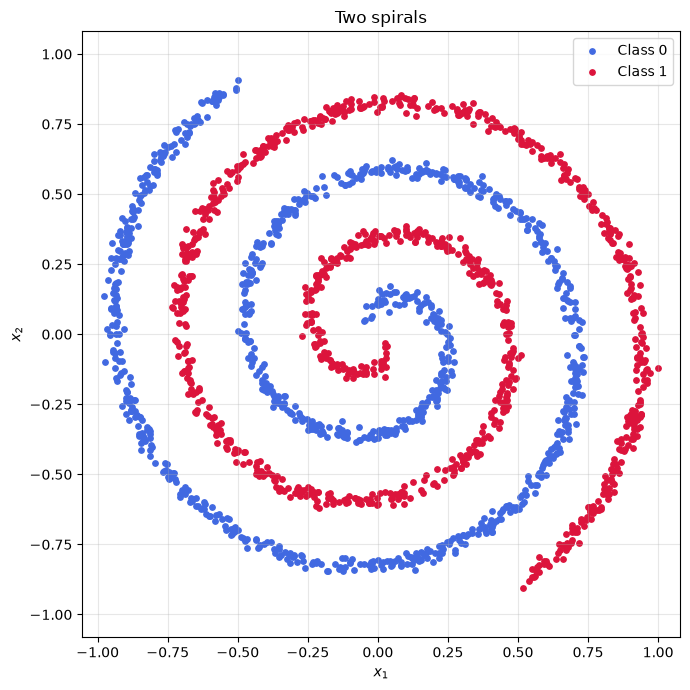

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1],
            c='royalblue', s=15, label='Class 0')
plt.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1],
            c='crimson', s=15, label='Class 1')

plt.title('Two spirals')
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.legend()
plt.axis('equal')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
class MLP:
    def __init__(self, sizes, activations, cost):
        if len(sizes) != len(activations) + 1:
            raise ValueError('Wrong sizes of \'sizes\' and \'activations\'!')
        self.num_layers = len(sizes)
        self.sizes = sizes
        self.biases = [np.random.normal(loc=0, scale=0.2, size=(y, 1)) 
                       for y in sizes[1:]]
        self.weights = [np.random.normal(loc=0, scale=0.2, size=(y,x)) 
                        for y, x in zip(sizes[1:], sizes[:-1])]
        self.act_funcs = activations
        self.cost = cost

    def sigmoid(self, x):
        return 1.0 / (1.0 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return np.exp(-x) / np.square(1 + np.exp(-x))

    def relu(self, x):
        return np.maximum(0, x)

    def cost_derivative(self, output_activations, y):
        return output_activations - y

    def activate(self, x, func_type: str):
        if func_type == 'relu':
            return self.relu(x)
        if func_type == 'sigmoid':
            return self.sigmoid(x)
        return x

    def activation_derivative(self, x, func_type: str):
        if func_type == 'relu':
            return (x > 0).astype(float)
        if func_type == 'sigmoid':
            return self.sigmoid_derivative(x)
        return np.ones_like(x)

    def feedforward(self, x):
        z = np.asarray(x, dtype=float)
        if z.ndim == 1:
            z = z.reshape(-1, 1)
        elif z.ndim == 2:
            if z.shape[0] != self.sizes[0] and z.shape[1] == self.sizes[0]:
                z = z.T

        for b, w, a in zip(self.biases, self.weights, self.act_funcs):
            z = w @ z + b
            z = self.activate(z, a)
        return z

    def backprop(self, x, y):
        x = np.asarray(x).reshape(-1, 1)
        y = np.asarray(y).reshape(-1, 1)

        nabla_w = [np.zeros(w.shape) for w in self.weights]
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        z_s = []
        a_s = [x]
        for w, b, a in zip(self.weights, self.biases, self.act_funcs):
            z_s.append(w @ a_s[-1] + b)
            a_s.append(self.activate(z_s[-1], a))

        delta = self.cost_derivative(a_s[-1], y) \
            * self.activation_derivative(z_s[-1], self.act_funcs[-1])

        nabla_b[-1] = delta
        nabla_w[-1] = delta @ a_s[-2].T

        for l in range(2, self.num_layers):
            delta = (self.weights[-l+1].T @ delta) \
                * self.activation_derivative(z_s[-l], self.act_funcs[-l])

            nabla_b[-l] = delta
            nabla_w[-l] = delta @ a_s[-l-1].T

        return nabla_b, nabla_w

    def update_mini_batch(self, mini_batch, eta):
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]

        for x, y in mini_batch:
            delta_nabla_b, delta_nabla_w = self.backprop(x, y)
            nabla_b = [nb + dnb for nb, dnb in zip(nabla_b, delta_nabla_b)]
            nabla_w = [nw + dnw for nw, dnw in zip(nabla_w, delta_nabla_w)]

        self.biases = [b - (eta/len(mini_batch)) * nb for b, nb in zip(self.biases, nabla_b)]
        self.weights = [w - (eta/len(mini_batch)) * nw for w, nw in zip(self.weights, nabla_w)]

    def SGD(self, training_data, epochs, mini_batch_size, eta):
        training_data = list(training_data)

        n = len(training_data)
        for j in range(epochs):
            np.random.shuffle(training_data)
            mini_batches = [
                training_data[k:k+mini_batch_size]
                for k in range(0, n, mini_batch_size)
            ]

            for mini_batch in mini_batches:
                self.update_mini_batch(mini_batch, eta)
            

In [ ]:
training_data = [(X[i], y[i]) for i in range(len(X))]
training_data

[(array([0.2891155 , 0.53259066]), array([0.])),
 (array([-0.7747677 ,  0.64421871]), array([0.])),
 (array([-0.52290029, -0.71533948]), array([0.])),
 (array([ 0.3606614 , -0.69397166]), array([0.])),
 (array([-0.23983528, -0.31539419]), array([0.])),
 (array([-0.23188846, -0.33851701]), array([0.])),
 (array([ 0.25557644, -0.03872387]), array([0.])),
 (array([-0.9360028,  0.0867629]), array([0.])),
 (array([ 0.33585555, -0.70945387]), array([0.])),
 (array([-0.40523354, -0.74799449]), array([0.])),
 (array([0.06095647, 0.10752126]), array([0.])),
 (array([-0.66582374,  0.74922931]), array([0.])),
 (array([-0.91541788, -0.13721107]), array([0.])),
 (array([-0.48843452,  0.00534457]), array([0.])),
 (array([-0.40177173, -0.196689  ]), array([0.])),
 (array([-0.37643465, -0.20219186]), array([0.])),
 (array([-0.19059006,  0.52393956]), array([0.])),
 (array([ 0.6787326 , -0.32411735]), array([0.])),
 (array([0.59493713, 0.32379799]), array([0.])),
 (array([-0.26660982,  0.48075484]), ar

In [ ]:
layers = [2, 64, 64, 1]
acts = ['relu', 'relu', 'sigmoid']
mlp = MLP(layers, acts, 'mse')